# Hierarchical Clustering – End-to-End Machine Learning Project

## Project: California Housing Segmentation

Hierarchical Clustering is an **unsupervised machine learning algorithm** that groups similar observations based on distance or similarity.

Unlike supervised learning, clustering does not require a target variable `y`. The algorithm identifies hidden groups or patterns from input features.

### Main Types of Hierarchical Clustering

**1. Agglomerative Clustering – Bottom-Up Approach**

Each data point initially starts as an individual cluster. The most similar clusters are repeatedly merged until the required number of clusters remains.

**2. Divisive Clustering – Top-Down Approach**

All data points initially belong to one large cluster. The cluster is repeatedly divided into smaller clusters.

This project uses **Agglomerative Clustering** because it is a commonly used hierarchical clustering approach and is directly supported by Scikit-learn.

## 1. Import Required Libraries

In [1]:
# NumPy is used for numerical operations
import numpy as np

# Pandas is used for data manipulation
import pandas as pd

# Matplotlib is used for visualization
import matplotlib.pyplot as plt

## 2. Load the California Housing Dataset

The California Housing dataset is a tabular machine learning dataset containing numerical housing-related features.

The original dataset also contains a target value. The target is **not used in this project** because Hierarchical Clustering is an unsupervised learning algorithm.

In [2]:
# Import the California Housing dataset
from sklearn.datasets import fetch_california_housing

# Load the dataset
housing = fetch_california_housing()

# Convert only the input features into a Pandas DataFrame
df = pd.DataFrame(housing.data, columns=housing.feature_names)

# Display first 5 rows
print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  


## 3. Understand the Dataset

In [3]:
# Display dataset shape
print("Dataset Shape:", df.shape)

# Display column names
print("\nColumn Names:")
print(df.columns)

# Display dataset information
print("\nDataset Information:")
df.info()

# Display statistical summary
print("\nStatistical Summary:")
print(df.describe())

Dataset Shape: (20640, 8)

Column Names:
Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB

Statistical Summary:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   

### Why is dataset understanding required?

Before clustering, the dataset must be examined for its size, features, data types, missing values, and numerical ranges.

`describe()` is especially useful because distance-based algorithms can be influenced by features with very different numerical scales and unusual values.

## 4. Check Data Quality

In [4]:
# Check missing values
# Missing values can prevent correct distance calculation
print("Missing Values:")
print(df.isnull().sum())

# Check total missing values
print("\nTotal Missing Values:", df.isnull().sum().sum())

# Check duplicate records
# Duplicate observations may repeatedly influence the same data pattern
print("\nDuplicate Records:", df.duplicated().sum())

# Display duplicate rows
duplicate_rows = df[df.duplicated(keep=False)]

print("\nDuplicate Rows:")
print(duplicate_rows)

# Check data types
# Hierarchical Clustering requires numerical input
print("\nData Types:")
print(df.dtypes)

Missing Values:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64

Total Missing Values: 0

Duplicate Records: 0

Duplicate Rows:
Empty DataFrame
Columns: [MedInc, HouseAge, AveRooms, AveBedrms, Population, AveOccup, Latitude, Longitude]
Index: []

Data Types:
MedInc        float64
HouseAge      float64
AveRooms      float64
AveBedrms     float64
Population    float64
AveOccup      float64
Latitude      float64
Longitude     float64
dtype: object


## 5. Remove Duplicate Records

In [5]:
# Remove duplicate records
df = df.drop_duplicates()

# Reset the index after removing rows
df = df.reset_index(drop=True)

# Validate duplicate removal
print("Duplicate Records After Cleaning:", df.duplicated().sum())

print("Dataset Shape After Removing Duplicates:", df.shape)

Duplicate Records After Cleaning: 0
Dataset Shape After Removing Duplicates: (20640, 8)


## 6. Sample the Dataset

Hierarchical Clustering can become computationally expensive for a large number of observations because it evaluates relationships between many data points.

The California Housing dataset contains more than 20,000 records. A reproducible sample of 500 records is selected to make linkage calculation and dendrogram visualization practical.

`random_state=42` ensures that the same sample is selected whenever the code is executed.

In [6]:
# Select 500 reproducible records
df = df.sample(n=500, random_state=42)

# Reset index after sampling
df = df.reset_index(drop=True)

print("Sampled Dataset Shape:", df.shape)

Sampled Dataset Shape: (500, 8)


## 7. Select Input Features

Hierarchical Clustering is an unsupervised learning algorithm.

Therefore:

- `x` contains input features.
- There is no target variable `y`.
- The original California Housing target is not used for clustering.

In [7]:
# Copy all input features into x
x = df.copy()

print(x.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  1.6812      25.0  4.192201   1.022284      1392.0  3.877437     36.06   
1  2.5313      30.0  5.039384   1.193493      1565.0  2.679795     35.14   
2  3.4801      52.0  3.977155   1.185877      1310.0  1.360332     37.80   
3  5.7376      17.0  6.163636   1.020202      1705.0  3.444444     34.28   
4  3.7250      34.0  5.492991   1.028037      1063.0  2.483645     36.62   

   Longitude  
0    -119.01  
1    -119.46  
2    -122.44  
3    -118.72  
4    -121.93  


## 8. Feature Scaling

Hierarchical Clustering is a distance-based algorithm. The California Housing features have different numerical scales.

For example, one feature may contain small decimal values while another may contain much larger values. Without scaling, large-scale features can dominate the distance calculation.

`StandardScaler` standardizes each feature so that it has approximately:

- Mean = 0
- Standard Deviation = 1

Formula:

**z = (x - mean) / standard deviation**

In [8]:
# Import StandardScaler
from sklearn.preprocessing import StandardScaler

# Create StandardScaler object
scaler = StandardScaler()

# Scale all input features
x_scaled = scaler.fit_transform(x)

print(x_scaled)

[[-1.06497706 -0.33483548 -0.60191972 ...  1.28672679  0.2682759
   0.21520369]
 [-0.65788983  0.07290378 -0.17647923 ... -0.38359369 -0.16590386
  -0.01394226]
 [-0.20353815  1.8669565  -0.70991198 ... -2.22381248  1.08944198
  -1.53139767]
 ...
 [ 0.8361361   0.31754733  0.68977974 ... -0.36164959  1.19326757
  -1.59759539]
 [-0.60574091  1.13302584 -0.84541973 ... -0.12410198 -0.68975119
   0.53600803]
 [ 0.80093916 -0.66102688  1.06839804 ...  0.06866545  1.15551281
  -1.32262025]]


## 9. Linkage Concepts

A **linkage method** determines how the distance between clusters is calculated during hierarchical merging.

### Common Linkage Methods

**Single Linkage:** Uses the minimum distance between two clusters. It may create long chain-like clusters.

**Complete Linkage:** Uses the maximum distance between two clusters. It generally produces more compact clusters.

**Average Linkage:** Uses the average pairwise distance between observations in two clusters.

**Ward Linkage:** Merges clusters that produce the smallest increase in within-cluster variance.

This project uses **Ward Linkage** because the data is numerical and scaled, and the objective is to form compact clusters.

## 10. Create the Linkage Matrix

In [9]:
# Import linkage
from scipy.cluster.hierarchy import linkage

# Create the hierarchical linkage matrix
# Ward linkage minimizes the increase in within-cluster variance
linkage_matrix = linkage(x_scaled, method="ward")

print("Linkage Matrix:")
print(linkage_matrix)

Linkage Matrix:
[[2.30000000e+01 7.60000000e+01 1.92040525e-01 2.00000000e+00]
 [6.00000000e+00 4.87000000e+02 2.61636131e-01 2.00000000e+00]
 [2.14000000e+02 2.43000000e+02 3.07541137e-01 2.00000000e+00]
 ...
 [9.94000000e+02 9.95000000e+02 2.52767134e+01 3.08000000e+02]
 [4.66000000e+02 9.91000000e+02 3.19568324e+01 1.92000000e+02]
 [9.96000000e+02 9.97000000e+02 3.99595814e+01 5.00000000e+02]]


### What is a Linkage Matrix?

The linkage matrix stores the hierarchical merging process.

Each row represents a merge and contains information about:

1. The first cluster or observation merged.
2. The second cluster or observation merged.
3. The distance at which the merge occurred.
4. The number of original observations in the newly formed cluster.

## 11. Plot the Dendrogram

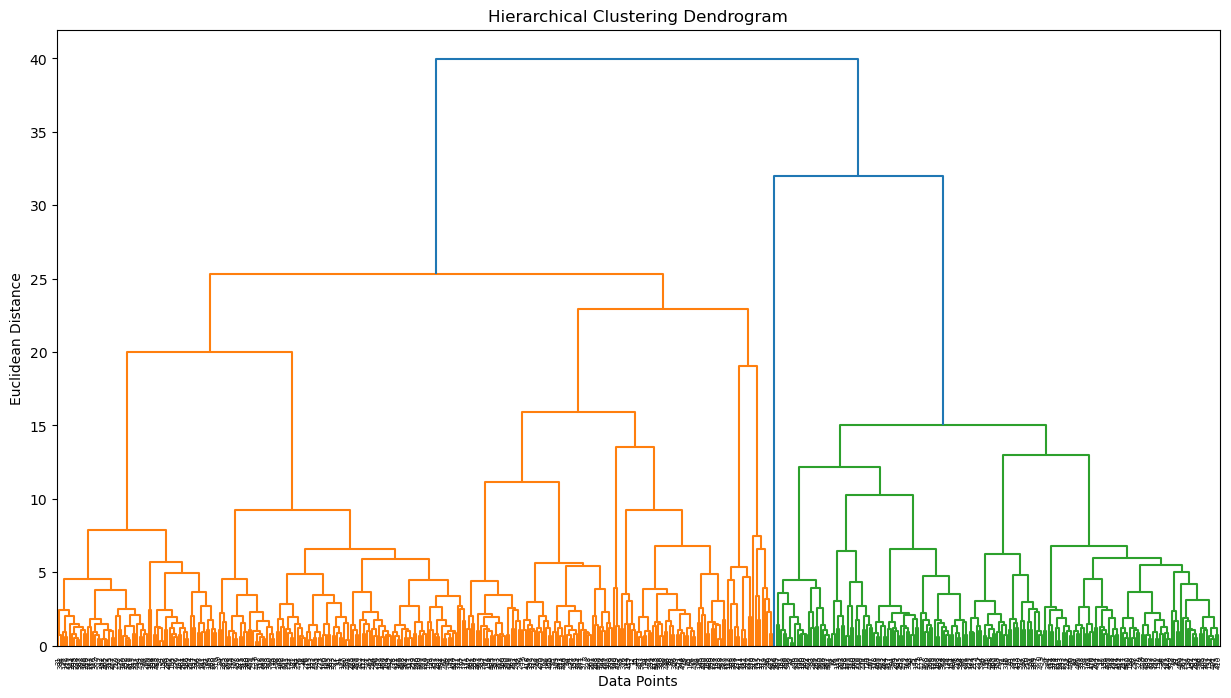

In [10]:
# Import dendrogram
from scipy.cluster.hierarchy import dendrogram

# Create a large figure for readability
plt.figure(figsize=(15, 8))

# Plot the dendrogram
dendrogram(linkage_matrix)

# Add labels and title
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance")
plt.title("Hierarchical Clustering Dendrogram")

# Display the graph
plt.show()

## 12. Dendrogram and Cluster Selection

A **dendrogram** is a tree-like visualization showing how observations and clusters are progressively merged.

The vertical axis represents the distance at which clusters merge.

To select the number of clusters:

1. Identify a large vertical gap between major merges.
2. Draw an imaginary horizontal line through that gap.
3. Count the major vertical branches crossed by the line.
4. The number of crossed branches represents the suggested number of clusters.

In the generated dendrogram, the final merge occurs near a Euclidean distance of 40. A horizontal cut around distance 35 crosses two major branches.

Therefore, the dendrogram **suggests 2 clusters**.

The dendrogram provides visual evidence. Silhouette Score is later used to numerically evaluate the clustering result.

In [11]:
# Store the selected cluster count
# The dendrogram suggests 2 major clusters
selected_clusters = 2

print("Selected Number of Clusters:", selected_clusters)

Selected Number of Clusters: 2


## 13. Agglomerative Clustering

Agglomerative Clustering follows a **bottom-up hierarchical approach**.

Process:

Individual Data Points  
↓  
Each Point Starts as a Cluster  
↓  
Find the Most Similar Clusters  
↓  
Merge Clusters  
↓  
Repeat the Process  
↓  
Stop at the Required Number of Clusters

Agglomerative Clustering is selected because the dendrogram and Ward linkage analysis are based on the same bottom-up hierarchical merging concept.

## 14. Create the Agglomerative Clustering Model

In [12]:
# Import AgglomerativeClustering
from sklearn.cluster import AgglomerativeClustering

# Create the Hierarchical Clustering model
hierarchical_model = AgglomerativeClustering(
    n_clusters=selected_clusters,  # Final number of clusters suggested by dendrogram
    metric="euclidean",            # Straight-line distance between observations
    linkage="ward"                 # Minimize increase in within-cluster variance
)

print(hierarchical_model)

AgglomerativeClustering(metric='euclidean')


### Model Parameters

**n_clusters:** Specifies the final number of clusters. The value 2 is selected from the dendrogram interpretation.

**metric="euclidean":** Uses straight-line distance between observations. Ward linkage works with Euclidean distance.

**linkage="ward":** Merges clusters that produce the smallest increase in within-cluster variance.

### Other Distance Metrics

**Manhattan Distance:** Sum of absolute differences between feature values.

**Cosine Distance:** Measures the difference in direction or orientation of vectors.

**Minkowski Distance:** Generalized distance measure that includes Euclidean and Manhattan distance as special cases.

Ward linkage specifically requires Euclidean distance in Scikit-learn.

## 15. Train the Model and Assign Cluster Labels

In [13]:
# fit_predict() fits the clustering model
# and assigns a cluster label to every observation
cluster_prediction = hierarchical_model.fit_predict(x_scaled)

print("Cluster Predictions:")
print(cluster_prediction)

Cluster Predictions:
[0 0 0 1 0 1 1 1 0 1 0 1 1 1 1 1 0 0 1 0 0 1 0 0 1 0 1 0 0 1 0 1 1 0 0 1 0
 1 0 1 1 0 0 1 1 1 1 1 1 0 0 1 1 0 1 0 1 1 1 1 1 1 0 0 1 1 0 0 1 1 0 0 0 1
 1 0 0 1 1 1 0 1 1 1 1 1 1 0 1 1 0 0 1 0 0 1 0 1 0 1 1 1 1 1 1 1 1 1 0 0 0
 1 1 0 0 1 1 1 1 1 0 1 0 1 1 0 1 1 1 0 1 1 0 0 0 1 0 1 0 1 1 1 1 1 1 1 0 0
 0 1 1 0 1 1 0 1 1 1 0 1 1 1 1 0 0 1 1 0 1 0 0 1 1 1 0 1 0 1 0 0 0 0 1 0 0
 1 1 1 0 1 1 0 1 1 0 0 1 1 1 1 0 1 0 0 1 0 0 0 1 0 1 1 1 1 0 1 1 0 0 1 1 0
 0 1 0 0 1 1 1 1 1 1 1 0 0 0 0 1 1 1 1 1 1 0 1 1 1 1 1 0 0 0 1 0 1 1 1 1 1
 1 1 0 0 1 0 1 1 0 1 1 1 0 1 1 1 1 0 0 1 1 1 1 0 0 1 1 0 1 0 1 1 1 1 1 1 0
 1 0 0 1 1 0 1 1 0 0 1 0 1 1 1 1 1 1 1 1 0 1 1 1 0 1 1 1 1 1 1 1 1 1 0 1 0
 1 0 0 1 1 0 1 0 1 1 1 1 0 0 0 1 0 1 1 1 0 1 0 1 1 1 1 0 1 1 1 1 1 1 0 0 1
 0 0 0 0 0 1 1 1 0 1 1 1 1 1 0 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 0 0 1 1 0 0 1
 1 0 1 0 1 1 1 0 1 1 0 1 1 0 0 1 1 0 1 1 0 1 1 0 1 1 1 1 0 0 0 1 1 1 1 1 1
 0 1 1 1 0 0 0 1 0 0 0 1 1 1 1 0 0 0 1 1 0 0 0 0 1 0 1 1 1 0 1 1 0 0 1 0 0
 1 1

### Why use fit_predict()?

`fit_predict()` performs two operations:

1. Learns the hierarchical cluster structure.
2. Assigns a cluster label to every observation.

Cluster labels such as 0 and 1 are only identifiers. They do not represent ranking.

Cluster 1 is not greater or better than Cluster 0.

## 16. Display Unique Cluster Labels

In [14]:
# Display unique cluster identifiers
print("Cluster Labels:")
print(np.unique(cluster_prediction))

Cluster Labels:
[0 1]


## 17. Add Cluster Labels to the Dataset

In [15]:
# Add predicted cluster labels to the DataFrame
# This allows cluster-wise analysis of the original features
df["Cluster"] = cluster_prediction

print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  1.6812      25.0  4.192201   1.022284      1392.0  3.877437     36.06   
1  2.5313      30.0  5.039384   1.193493      1565.0  2.679795     35.14   
2  3.4801      52.0  3.977155   1.185877      1310.0  1.360332     37.80   
3  5.7376      17.0  6.163636   1.020202      1705.0  3.444444     34.28   
4  3.7250      34.0  5.492991   1.028037      1063.0  2.483645     36.62   

   Longitude  Cluster  
0    -119.01        0  
1    -119.46        0  
2    -122.44        0  
3    -118.72        1  
4    -121.93        0  


## 18. Display Cluster Counts

In [16]:
# Count the number of records in each cluster
print("Cluster Counts:")

print(df["Cluster"].value_counts().sort_index())

Cluster Counts:
Cluster
0    192
1    308
Name: count, dtype: int64


### Why check Cluster Counts?

Cluster counts show how observations are distributed among clusters.

A very small cluster may indicate:

- Rare observations
- Outliers
- A genuine small group
- An unsuitable cluster structure

Cluster counts should be interpreted together with cluster profiles and evaluation metrics.

## 19. Cluster Profiling

In [17]:
# Calculate the average feature values for every cluster
print("Cluster Analysis:")

print(df.groupby("Cluster").mean())

Cluster Analysis:
           MedInc   HouseAge  AveRooms  AveBedrms   Population  AveOccup  \
Cluster                                                                    
0        3.628617  28.822917  5.503317   1.073341  1214.484375  2.808300   
1        4.077516  29.282468  5.320672   1.088983  1561.620130  3.046184   

          Latitude   Longitude  
Cluster                         
0        37.870677 -121.578490  
1        34.008442 -118.094935  


### What is Cluster Profiling?

Cluster labels alone do not explain the meaning of a cluster.

**Cluster Profiling** is the process of studying the characteristics of each cluster.

`groupby("Cluster").mean()` calculates average feature values for each cluster. These averages help identify differences in median income, house age, average rooms, population, occupancy, and geographical features.

Clusters can then be described based on their dominant characteristics.

## 20. Store Cluster Analysis

In [18]:
# Store cluster-wise average values
cluster_analysis = df.groupby("Cluster").mean()

print("Cluster Analysis:")
print(cluster_analysis)

Cluster Analysis:
           MedInc   HouseAge  AveRooms  AveBedrms   Population  AveOccup  \
Cluster                                                                    
0        3.628617  28.822917  5.503317   1.073341  1214.484375  2.808300   
1        4.077516  29.282468  5.320672   1.088983  1561.620130  3.046184   

          Latitude   Longitude  
Cluster                         
0        37.870677 -121.578490  
1        34.008442 -118.094935  


## 21. Silhouette Score

Silhouette Score evaluates cluster quality using two concepts:

**Cohesion:** Measures how close an observation is to other observations in its own cluster.

**Separation:** Measures how far an observation is from other clusters.

Silhouette Score ranges from **-1 to +1**.

- Near +1: Well-separated clusters.
- Near 0: Overlapping clusters.
- Near -1: Observations may be assigned to unsuitable clusters.

A higher score generally indicates better cluster separation.

In [19]:
# Import Silhouette Score
from sklearn.metrics import silhouette_score

# Calculate cluster quality
silhouette = silhouette_score(x_scaled, cluster_prediction)

print("Silhouette Score:", silhouette)

Silhouette Score: 0.25316360728929543


## 22. Compare Different Numbers of Clusters

The dendrogram suggests 2 clusters. However, nearby cluster counts can also be evaluated numerically.

Silhouette Score is calculated for cluster counts from 2 to 6.

One cluster is not tested because Silhouette Score requires at least two clusters to compare cohesion and separation.

In [20]:
# Create an empty list to store Silhouette Scores
silhouette_scores = []

# Test cluster counts from 2 to 6
for k in range(2, 7):

    # Create Agglomerative Clustering model
    model = AgglomerativeClustering(
        n_clusters=k,
        metric="euclidean",
        linkage="ward"
    )

    # Fit the model and assign cluster labels
    labels = model.fit_predict(x_scaled)

    # Calculate Silhouette Score
    score = silhouette_score(x_scaled, labels)

    # Store the score
    silhouette_scores.append(score)

    # Display the score for each cluster count
    print("Number of Clusters:", k, "Silhouette Score:", score)

Number of Clusters: 2 Silhouette Score: 0.25316360728929543
Number of Clusters: 3 Silhouette Score: 0.25125110857874816
Number of Clusters: 4 Silhouette Score: 0.22635526814906226
Number of Clusters: 5 Silhouette Score: 0.23385327798298744
Number of Clusters: 6 Silhouette Score: 0.2080842417463463


## 23. Plot Silhouette Scores

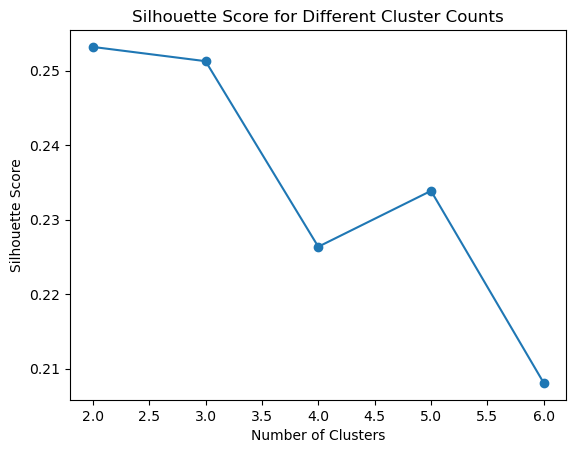

In [21]:
# Plot cluster counts against Silhouette Scores
plt.plot(range(2, 7), silhouette_scores, marker="o")

# Add labels and title
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different Cluster Counts")

# Display the graph
plt.show()

### Dendrogram vs Silhouette Score

**Dendrogram:** Provides a visual representation of the hierarchical merging structure and suggests possible cluster cuts.

**Silhouette Score:** Provides a numerical measure of cluster cohesion and separation.

The dendrogram suggests 2 clusters for this sampled dataset. Silhouette Scores are compared to validate and investigate the quality of different cluster counts.

The final cluster decision should consider dendrogram structure, evaluation scores, cluster profiles, and domain requirements.

## 24. Two-Feature Cluster Visualization

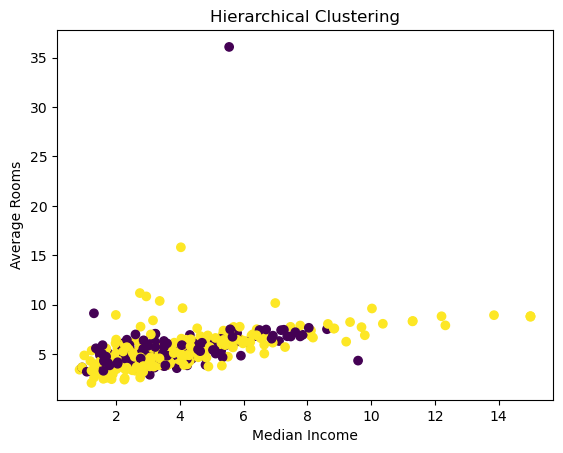

In [22]:
# Create a 2D scatter plot using Median Income and Average Rooms
# The model was trained using all scaled features
# These two features are used only for visualization
plt.scatter(
    df["MedInc"],
    df["AveRooms"],
    c=df["Cluster"]
)

plt.xlabel("Median Income")
plt.ylabel("Average Rooms")
plt.title("Hierarchical Clustering")

plt.show()

## 25. PCA for Cluster Visualization

The dataset contains multiple features and cannot be directly displayed in a two-dimensional graph.

**Principal Component Analysis (PCA)** is a dimensionality reduction technique.

In this project, PCA is used **only for visualization**. The Hierarchical Clustering model was trained using all scaled input features.

`n_components=2` reduces the high-dimensional scaled data into two principal components that can be displayed on a 2D scatter plot.

In [23]:
# Import PCA
from sklearn.decomposition import PCA

# Create PCA object with two components
pca = PCA(n_components=2)

# Transform scaled data into two dimensions
x_pca = pca.fit_transform(x_scaled)

print("PCA Data:")
print(x_pca)

PCA Data:
[[-7.62573988e-01 -5.67051235e-01]
 [-3.27441214e-02 -1.10783358e-01]
 [ 1.57446603e+00 -2.07036651e+00]
 [-3.97892496e-01  1.13467118e+00]
 [ 1.03463092e+00 -1.06941141e+00]
 [-9.44567547e-01  1.05305223e+00]
 [-4.61325320e-01  7.76508444e-01]
 [-1.18327898e+00  2.41001738e-01]
 [ 1.41329017e+00 -9.28046656e-01]
 [-8.50367460e-02  1.01461015e+00]
 [ 1.09918300e+00 -1.05216709e+00]
 [-1.34460412e+00 -3.22551263e-01]
 [-2.00260974e+00  1.13616014e+00]
 [-1.08986530e+00  6.74278572e-01]
 [-5.82030935e-01  1.22781598e+00]
 [-1.89417147e+00  1.36859661e+00]
 [ 1.04824360e+00 -1.96666800e+00]
 [ 1.21086684e+00 -6.51772327e-01]
 [-1.31991699e+00  6.31857219e-01]
 [ 7.02850057e-01 -1.10861119e+00]
 [ 1.13003617e+00 -1.84521042e+00]
 [-6.12995163e-01 -2.47233617e-01]
 [ 4.29797915e-01  4.94632313e-01]
 [ 1.63947420e+00 -5.84534058e-01]
 [-1.46353141e+00  1.13766491e+00]
 [-8.96805190e-01 -7.79903276e-01]
 [-1.22103485e+00  1.48364362e-01]
 [ 2.63572027e+00 -2.47160425e+00]
 [ 1.39671

## 26. Plot PCA Cluster Visualization

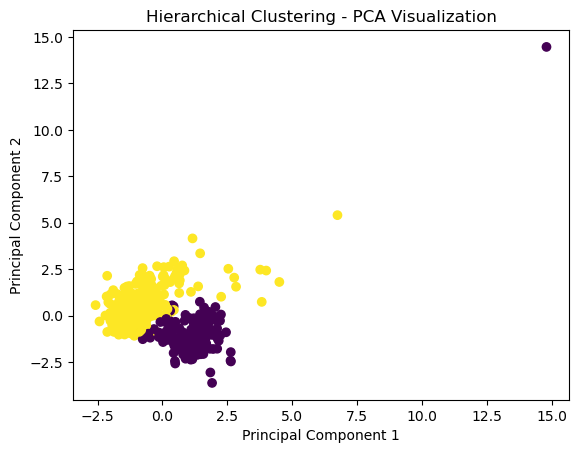

In [24]:
# Plot the two principal components
plt.scatter(
    x_pca[:, 0],
    x_pca[:, 1],
    c=cluster_prediction
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Hierarchical Clustering - PCA Visualization")

plt.show()

## 27. Display Complete Cluster Summary

In [25]:
# Display selected number of clusters
print("Number of Clusters:", hierarchical_model.n_clusters)

# Display number of records in each cluster
print("\nCluster Counts:")

print(df["Cluster"].value_counts().sort_index())

# Display average feature values for each cluster
print("\nCluster Analysis:")

print(df.groupby("Cluster").mean())

# Display cluster quality score
print("\nSilhouette Score:", silhouette)

Number of Clusters: 2

Cluster Counts:
Cluster
0    192
1    308
Name: count, dtype: int64

Cluster Analysis:
           MedInc   HouseAge  AveRooms  AveBedrms   Population  AveOccup  \
Cluster                                                                    
0        3.628617  28.822917  5.503317   1.073341  1214.484375  2.808300   
1        4.077516  29.282468  5.320672   1.088983  1561.620130  3.046184   

          Latitude   Longitude  
Cluster                         
0        37.870677 -121.578490  
1        34.008442 -118.094935  

Silhouette Score: 0.25316360728929543


## 28. Complete Hierarchical Clustering Workflow

Load Dataset  
↓  
Understand Dataset  
↓  
Check Missing Values  
↓  
Check Duplicate Records  
↓  
Remove Duplicates  
↓  
Sample Large Dataset  
↓  
Select Input Features  
↓  
Feature Scaling  
↓  
Select Linkage Method  
↓  
Create Linkage Matrix  
↓  
Plot Dendrogram  
↓  
Interpret Dendrogram  
↓  
Select Number of Clusters  
↓  
Create Agglomerative Clustering Model  
↓  
Fit Model and Assign Clusters  
↓  
Check Cluster Counts  
↓  
Perform Cluster Profiling  
↓  
Calculate Silhouette Score  
↓  
Compare Cluster Counts  
↓  
Visualize Clusters  
↓  
PCA Visualization  
↓  
Final Cluster Summary

## Key Concepts Summary

- Hierarchical Clustering groups similar observations using a hierarchy of cluster merges or divisions.
- Agglomerative Clustering follows a bottom-up approach.
- Divisive Clustering follows a top-down approach.
- Linkage methods define how cluster-to-cluster distance is evaluated.
- Ward linkage minimizes the increase in within-cluster variance.
- StandardScaler is important because clustering is distance-based.
- A dendrogram visually represents the hierarchical merging process.
- A horizontal dendrogram cut can suggest the number of clusters.
- Silhouette Score measures cluster cohesion and separation.
- Cluster Profiling explains the characteristics of discovered groups.
- PCA can reduce high-dimensional data to two dimensions for visualization.
- Cluster labels are identifiers and do not represent ranking.